In [1]:
import pandas as pd
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import ast

archivos = glob.glob("DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv")
datos_nodos = {}

# ── Load all files ──────────────────────────────────────────────────────────
EXCLUDE = {
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota", # not enough data
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota", # atipical 
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota", # poor quality -- brocken mux 
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota", # poorest measure quality -- without antenna
}

for archivo in tqdm(archivos, desc="Cargando CSVs"):
    nombre_nodo = archivo.replace('.csv', '')
    if nombre_nodo in EXCLUDE:
        print(f"⏭️  Skipped: {nombre_nodo}")
        continue
    datos_nodos[nombre_nodo] = pd.read_csv(archivo)

Cargando CSVs:  40%|████      | 4/10 [00:16<00:24,  4.03s/it]⏭️  Skipped: DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota
⏭️  Skipped: DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota
Cargando CSVs: 100%|██████████| 10/10 [00:28<00:00,  2.86s/it]


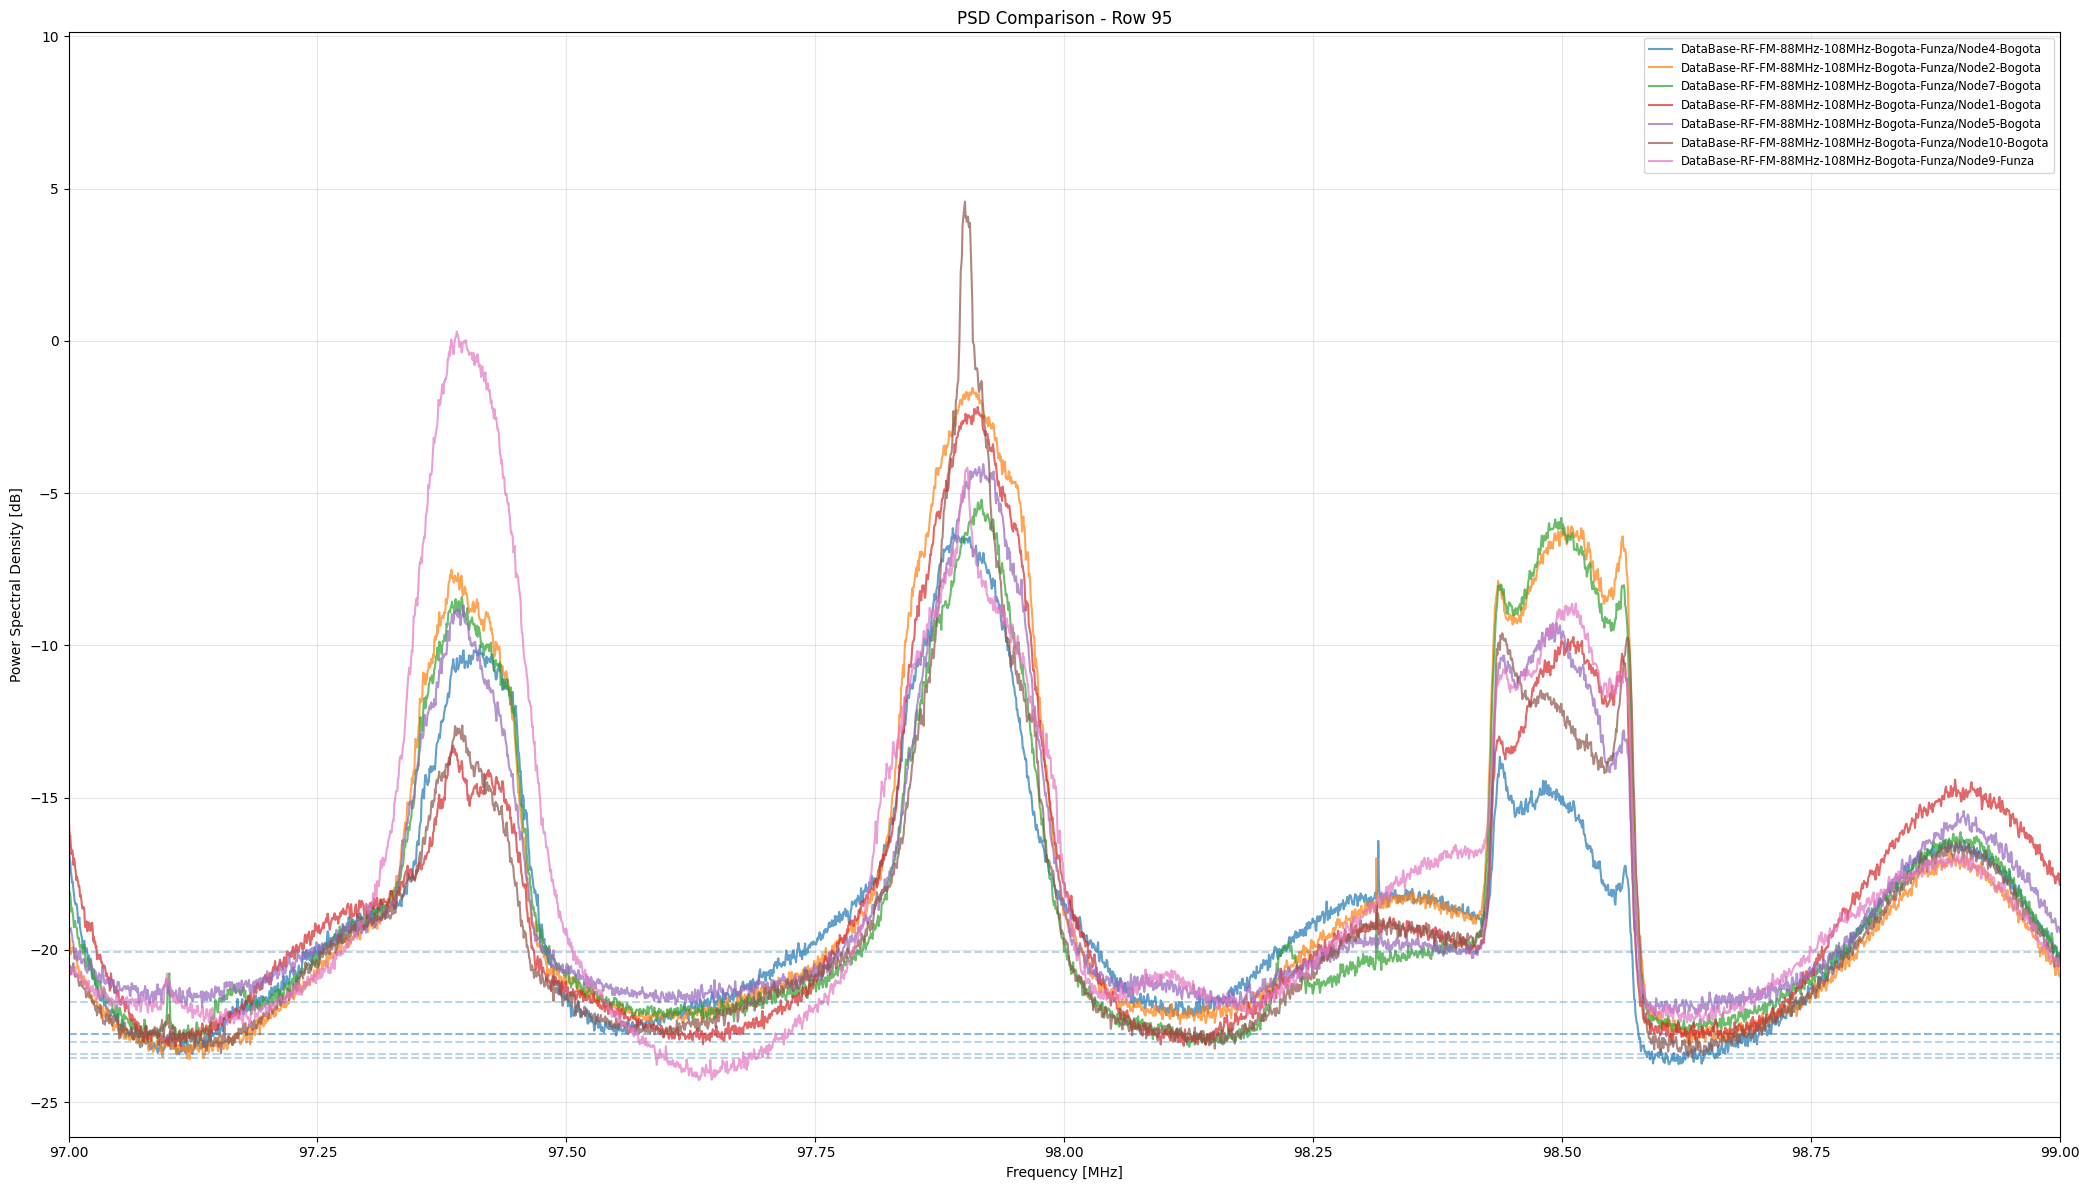


📊 Noise Floor Estimates (Row 95):
--------------------------------------------------
Node order: ['DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node10-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node2-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node4-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node7-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node9-Funza']
Noise floors [dB]: [-23.41532905 -23.02551748 -22.75486004 -23.53954611 -20.07343937
 -22.77744562 -21.70509125]
Statistics → Mean: -22.47 dB, Std: 1.12 dB, Min: -23.54 dB, Max: -20.07 dB

📋 Detailed Table:
Node                 Noise Floor [dB]
-----------------------------------
DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota          -23.42
DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node10-Bogota          -23.03
DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node2-Bogota          -22.75
DataBase-R

In [10]:
import ast
import numpy as np
import matplotlib.pyplot as plt

ROW_PLOT = 95  # Change this to plot a different row [0, 105]

# Container: {node_name: {row_index: pxx_array}}
pxx_indexed = {}

# Container for noise floor estimates: {node_name: noise_floor_db}
noise_floor_estimates = {}

plt.figure(figsize=(21, 12))

for nombre_nodo, df in datos_nodos.items():
    # Initialize nested dict for this node if needed
    if nombre_nodo not in pxx_indexed:
        pxx_indexed[nombre_nodo] = {}
    
    # Extract and parse the pxx list from the specified row
    pxx_raw = df['pxx'].iloc[ROW_PLOT]
    pxx = np.array(ast.literal_eval(pxx_raw))  # Convert string → list → numpy array
    
    # Store in indexed structure
    pxx_indexed[nombre_nodo][ROW_PLOT] = pxx
    
    # Compute corresponding frequency axis (88–108 MHz band)
    frecuencias = np.linspace(88, 108, len(pxx))
    
    # Noise Floor via histogram (best for multimodal PSDs)
    N_bins = int(np.ceil(np.log2(len(pxx)) + 1))   # or keep a fixed value such as 32 or 64
    counts, bin_edges = np.histogram(pxx, bins=N_bins)
    k = np.argmax(counts)
    noise_floor_db = 0.5 * (bin_edges[k] + bin_edges[k + 1])
    
    # Store estimate
    noise_floor_estimates[nombre_nodo] = noise_floor_db
    
    # Plot each node data
    plt.plot(frecuencias, pxx, label=nombre_nodo, alpha=0.7)
    
    # Optional: visualize noise floor as horizontal dashed line per node
    plt.axhline(y=noise_floor_db, linestyle='--', alpha=0.3)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Power Spectral Density [dB]")
plt.title(f"PSD Comparison - Row {ROW_PLOT}")
plt.legend(loc='best', fontsize='small')
plt.xlim(97,99)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 🔹 Print array of noise floor estimates
print(f"\n📊 Noise Floor Estimates (Row {ROW_PLOT}):")
print("-" * 50)

# As a simple array (ordered by node name)
node_names = sorted(noise_floor_estimates.keys())
noise_array = np.array([noise_floor_estimates[node] for node in node_names])

print("Node order:", node_names)
print("Noise floors [dB]:", noise_array)
print(f"Statistics → Mean: {np.mean(noise_array):.2f} dB, "
      f"Std: {np.std(noise_array):.2f} dB, "
      f"Min: {np.min(noise_array):.2f} dB, "
      f"Max: {np.max(noise_array):.2f} dB")

# Optional: formatted table output
print("\n📋 Detailed Table:")
print(f"{'Node':<20} {'Noise Floor [dB]':>15}")
print("-" * 35)
for node in node_names:
    print(f"{node:<20} {noise_floor_estimates[node]:>15.2f}")


📊 Noise Floor Alignment (Row 95)
------------------------------------------------------------
Global reference noise floor (mean): -22.47 dB
Per-node offsets to apply: {node: offset_dB}
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node4-Bogota → offset = +1.07 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node2-Bogota → offset = +0.28 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node7-Bogota → offset = +0.31 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota → offset = +0.95 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota → offset = -2.40 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node10-Bogota → offset = +0.56 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node9-Funza → offset = -0.77 dB


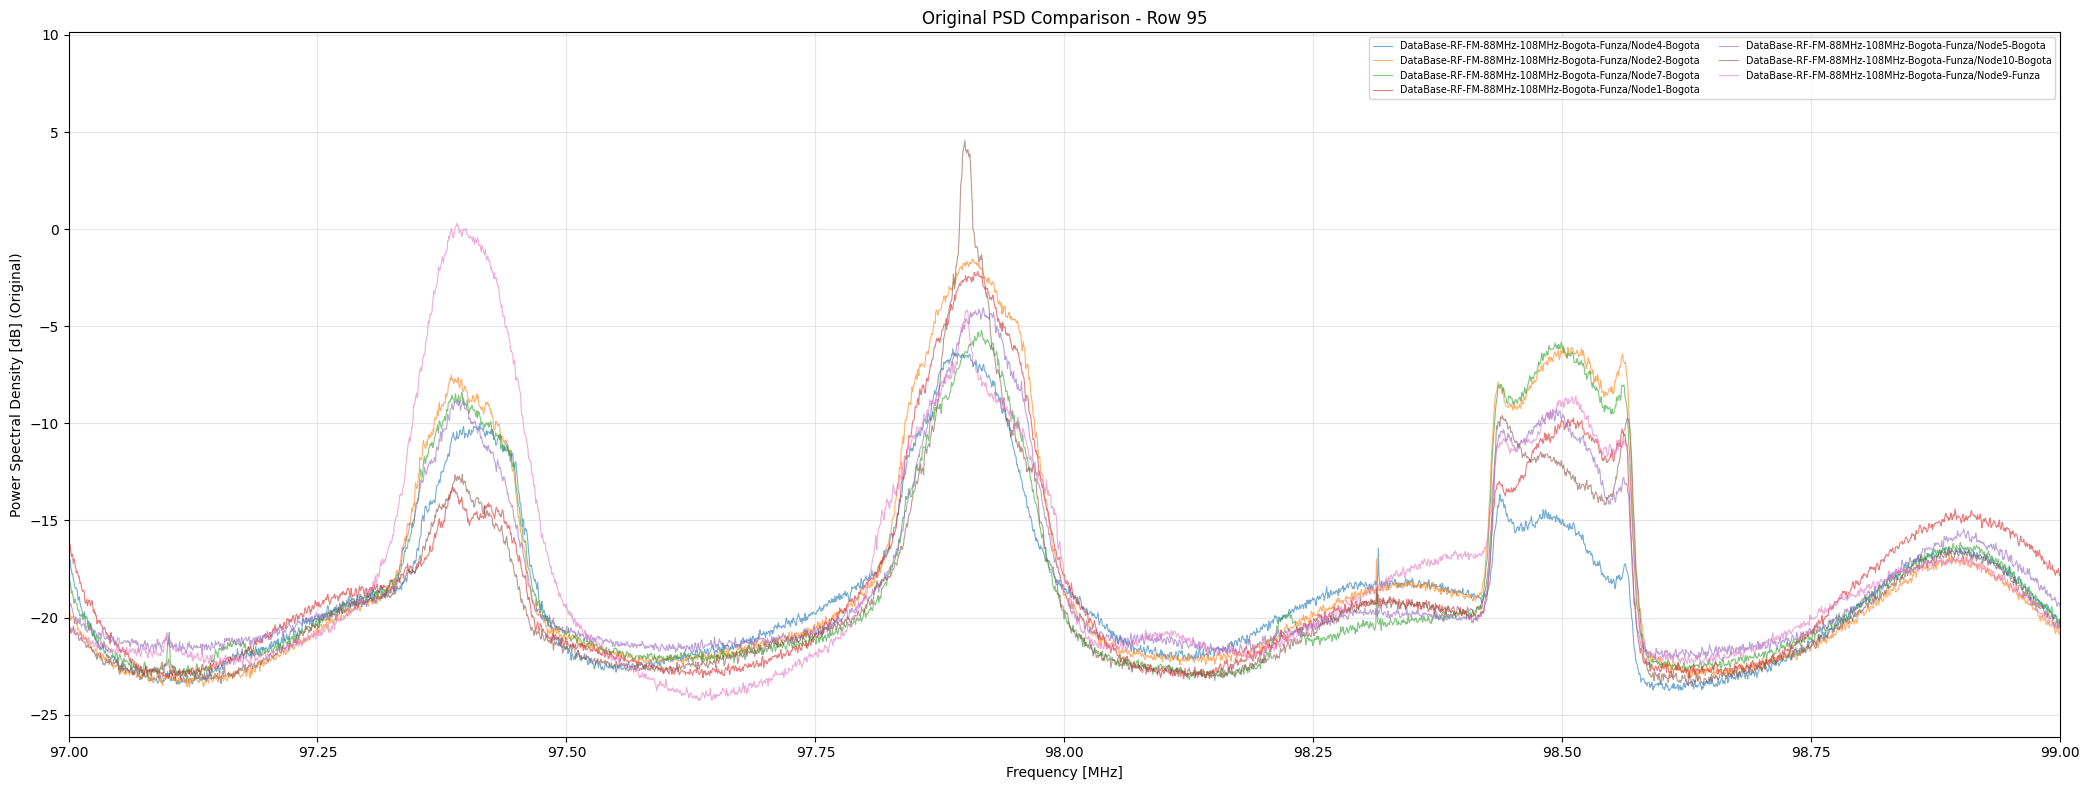

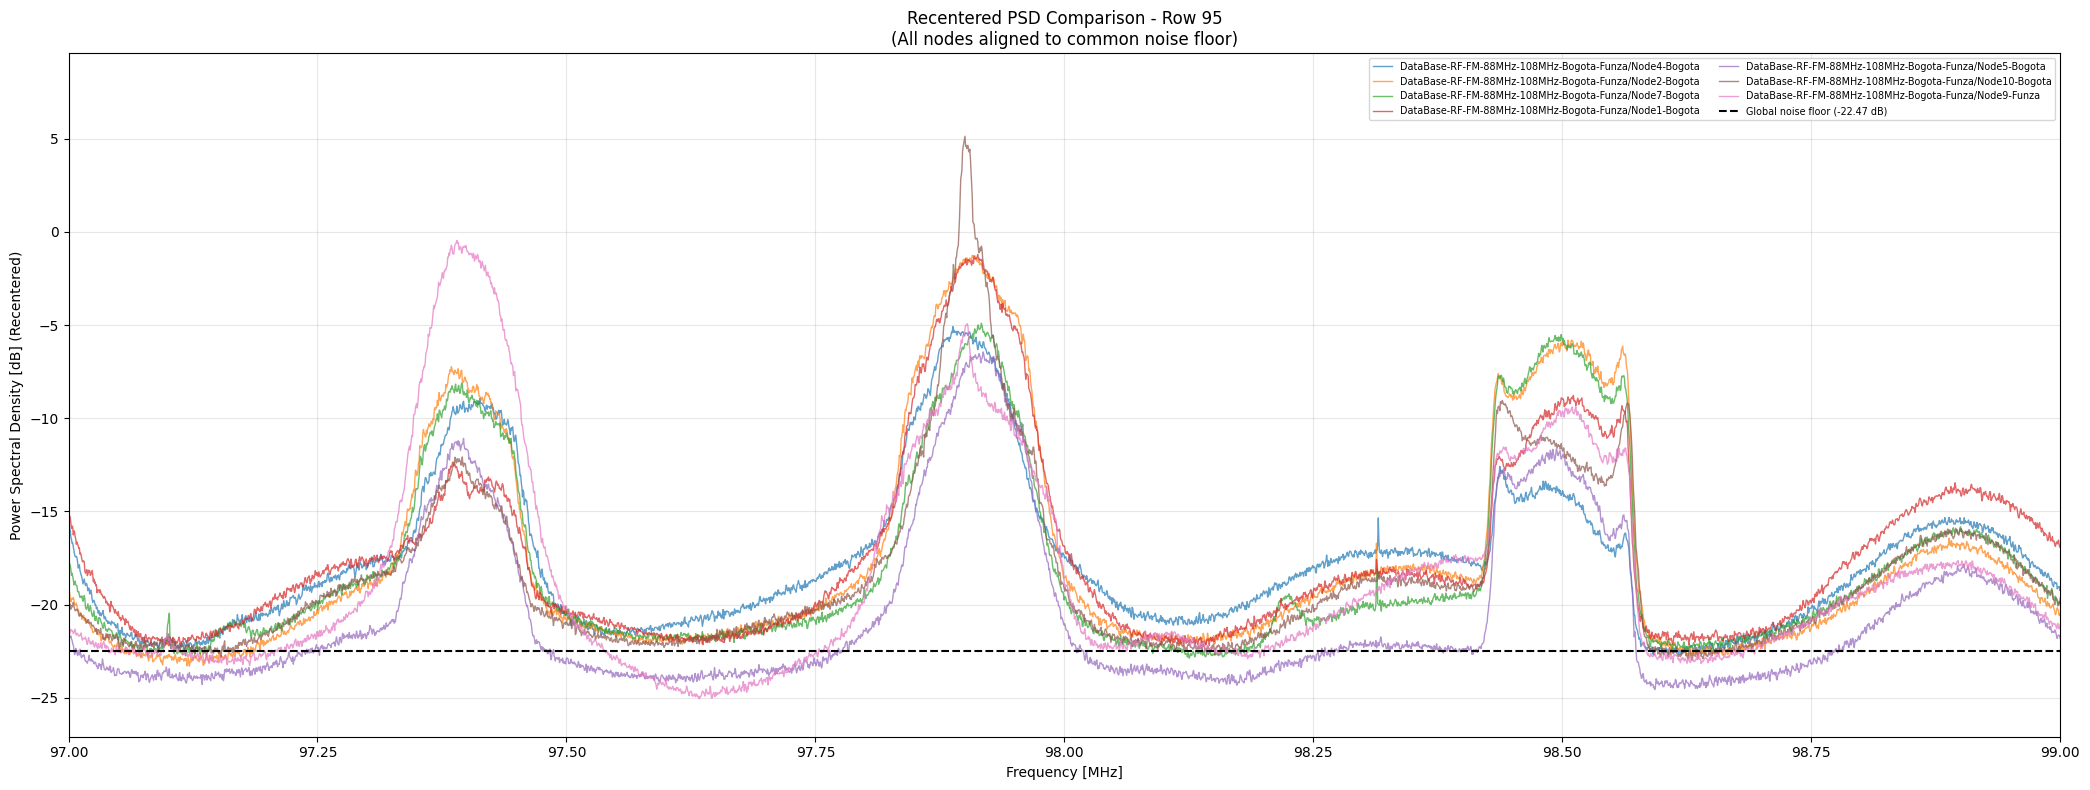


✅ Recentered data stored in 'pxx_recentered_indexed'
   pxx_recentered_indexed['DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node4-Bogota'] → aligned PSD array


In [16]:
import ast
import numpy as np
import matplotlib.pyplot as plt

ROW_PLOT = 95  # Change this to plot a different row [0, 105]

# Containers
pxx_indexed = {}
noise_floor_estimates = {}

# =============================================================================
# PASS 1: Estimate noise floor for each node (using histogram mode method)
# =============================================================================
for nombre_nodo, df in datos_nodos.items():
    if nombre_nodo not in pxx_indexed:
        pxx_indexed[nombre_nodo] = {}
    
    # Extract and parse pxx
    pxx_raw = df['pxx'].iloc[ROW_PLOT]
    pxx = np.array(ast.literal_eval(pxx_raw))
    pxx_indexed[nombre_nodo][ROW_PLOT] = pxx
    
    # Estimate noise floor: mode via histogram (robust for multimodal PSDs)
    N_bins = int(np.ceil(np.log2(len(pxx)) + 1))   # or keep a fixed value such as 32 or 64
    counts, bin_edges = np.histogram(pxx, bins=N_bins)
    k = np.argmax(counts)
    noise_floor_db = 0.5 * (bin_edges[k] + bin_edges[k + 1])
    noise_floor_estimates[nombre_nodo] = noise_floor_db

# =============================================================================
# Compute global reference: mean of all noise floor estimates
# =============================================================================
noise_array = np.array(list(noise_floor_estimates.values()))
global_noise_mean = np.mean(noise_array)

print(f"\n📊 Noise Floor Alignment (Row {ROW_PLOT})")
print("-" * 60)
print(f"Global reference noise floor (mean): {global_noise_mean:.2f} dB")
print(f"Per-node offsets to apply: {{node: offset_dB}}")
for node, nf in noise_floor_estimates.items():
    offset = global_noise_mean - nf
    print(f"  {node:<15} → offset = {offset:+.2f} dB")

# =============================================================================
# PASS 2: Plot ORIGINAL data (for comparison)
# =============================================================================
frecuencias = np.linspace(88, 108, len(pxx_indexed[nombre_nodo][ROW_PLOT]))  # assume uniform length

plt.figure(figsize=(21, 8))
for nombre_nodo, df in datos_nodos.items():
    pxx = pxx_indexed[nombre_nodo][ROW_PLOT]
    plt.plot(frecuencias, pxx, label=nombre_nodo, alpha=0.6, linewidth=0.8)
    
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power Spectral Density [dB] (Original)")
plt.title(f"Original PSD Comparison - Row {ROW_PLOT}")
plt.legend(loc='best', fontsize='x-small', ncol=2)
plt.xlim(97,99)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# PASS 3: Plot RECENTERED data (aligned to global noise floor)
# =============================================================================
plt.figure(figsize=(21, 8))

for nombre_nodo, df in datos_nodos.items():
    pxx_original = pxx_indexed[nombre_nodo][ROW_PLOT]
    node_noise_floor = noise_floor_estimates[nombre_nodo]
    
    # 🔹 Recenter: shift PSD so node's noise floor matches global mean
    offset = global_noise_mean - node_noise_floor
    pxx_recentered = pxx_original + offset
    
    plt.plot(frecuencias, pxx_recentered, label=nombre_nodo, alpha=0.7, linewidth=1.0)

# Visual reference: global noise floor line
plt.axhline(y=global_noise_mean, color='black', linestyle='--', linewidth=1.5, 
            label=f'Global noise floor ({global_noise_mean:.2f} dB)', zorder=5)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Power Spectral Density [dB] (Recentered)")
plt.title(f"Recentered PSD Comparison - Row {ROW_PLOT}\n(All nodes aligned to common noise floor)")
plt.legend(loc='best', fontsize='x-small', ncol=2)
plt.grid(True, alpha=0.3)
plt.xlim(97,99)

plt.tight_layout()
plt.show()

# =============================================================================
# Optional: Store recentered data for downstream use (e.g., MLP features)
# =============================================================================
pxx_recentered_indexed = {}
for nombre_nodo in datos_nodos.keys():
    pxx_orig = pxx_indexed[nombre_nodo][ROW_PLOT]
    offset = global_noise_mean - noise_floor_estimates[nombre_nodo]
    pxx_recentered_indexed[nombre_nodo] = pxx_orig + offset

print(f"\n✅ Recentered data stored in 'pxx_recentered_indexed'")
print(f"   pxx_recentered_indexed['{list(datos_nodos.keys())[0]}'] → aligned PSD array")


🔗 Computing pairwise correlations (Row 3)...

📊 Cumulative Correlation Scores (Row 3)
----------------------------------------------------------------------
Rank   Node                   Cumulative Score     Avg Corr
----------------------------------------------------------------------
1      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node2-Bogota             5.3832       0.8972
2      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node10-Bogota             5.3219       0.8870
3      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node4-Bogota             5.3041       0.8840
4      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node7-Bogota             5.3028       0.8838
5      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota             5.2521       0.8754
6      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota             5.2391       0.8732
7      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node9-Funza             4.6632       0.7772

🎯 Key Nodes:
   Highest cumulative correlation: DataBase-RF

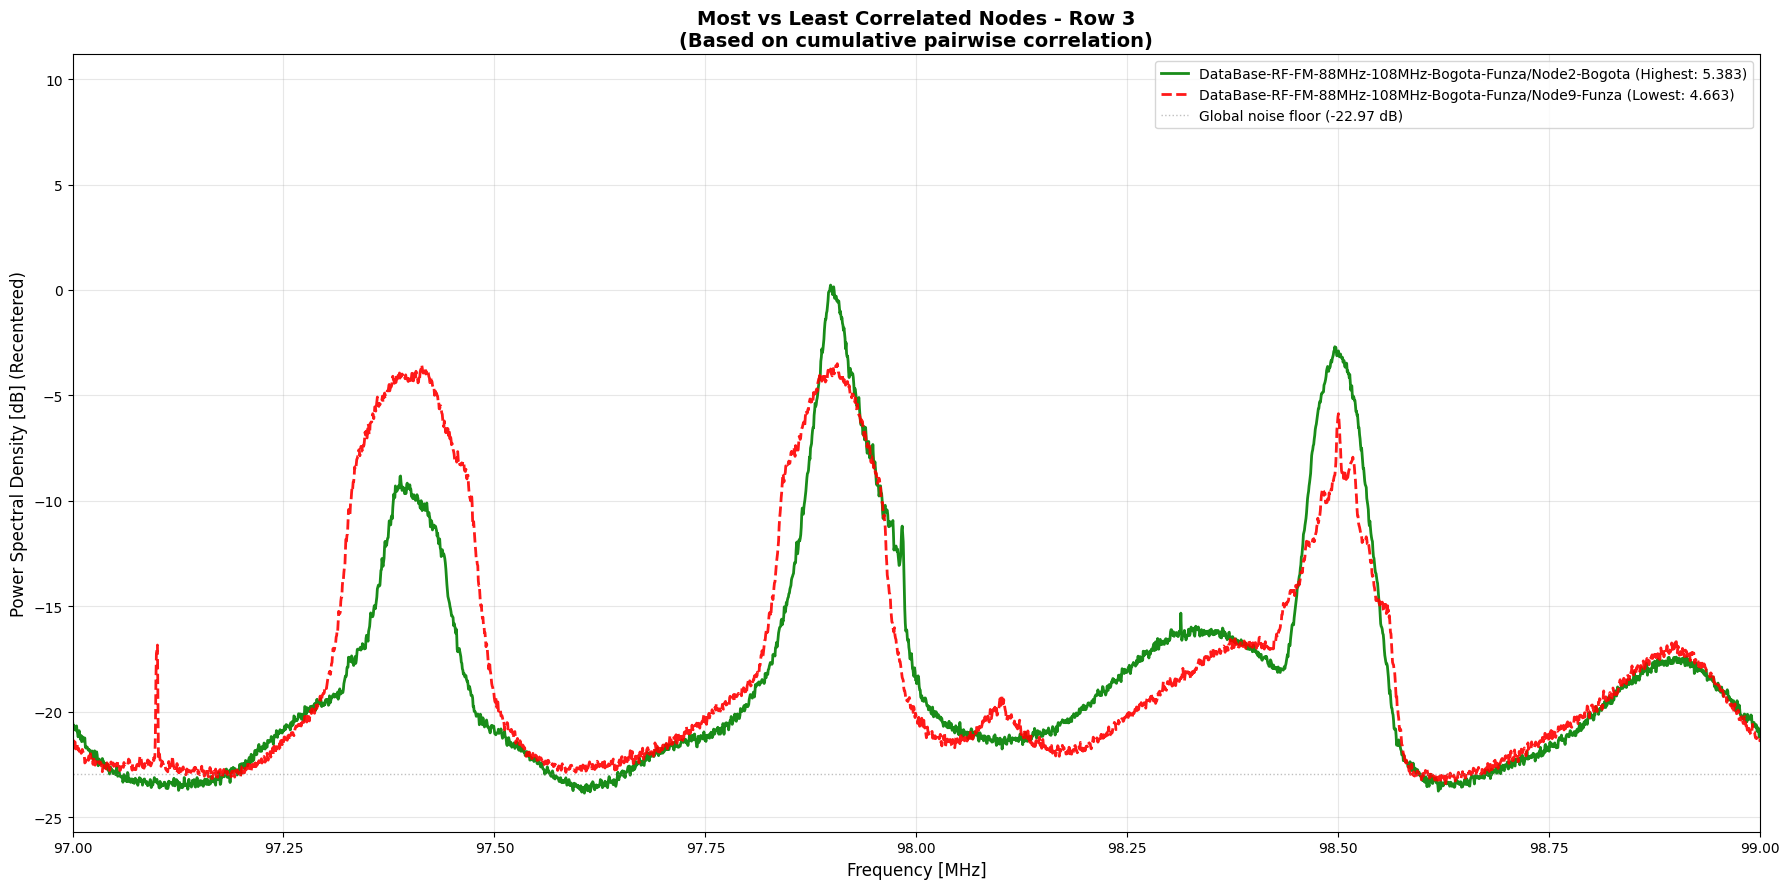


✅ Correlation analysis complete.
   Results stored in 'correlation_results' dictionary
   → Use 'correlation_results['most_representative']' for prototype selection
   → Use 'correlation_results['most_distinctive']' for anomaly detection


In [19]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

data_record = 3  # Change this to plot a different row [0, 22]

# Containers
pxx_indexed = {}
noise_floor_estimates = {}

# =============================================================================
# PASS 1: Estimate noise floor and store recentered PSDs
# =============================================================================
for nombre_nodo, df in datos_nodos.items():
    if nombre_nodo not in pxx_indexed:
        pxx_indexed[nombre_nodo] = {}
    
    pxx_raw = df['pxx'].iloc[data_record]
    pxx = np.array(ast.literal_eval(pxx_raw))
    pxx_indexed[nombre_nodo][data_record] = pxx
    
    # Estimate noise floor: mode via histogram
    N_bins = int(np.ceil(np.log2(len(pxx)) + 1))   # or keep a fixed value such as 32 or 64
    counts, bin_edges = np.histogram(pxx, bins=N_bins)
    k = np.argmax(counts)
    noise_floor_db = 0.5 * (bin_edges[k] + bin_edges[k + 1])
    noise_floor_estimates[nombre_nodo] = noise_floor_db

# Compute global reference noise floor
noise_array = np.array(list(noise_floor_estimates.values()))
global_noise_mean = np.mean(noise_array)

# Build recentered + Z-normalized PSD dictionary for correlation analysis
pxx_processed = {}
for nombre_nodo in datos_nodos.keys():
    pxx_orig = pxx_indexed[nombre_nodo][data_record]
    offset = global_noise_mean - noise_floor_estimates[nombre_nodo]
    pxx_recentered = pxx_orig + offset
    
    # 🔹 Z-normalize: zero mean, unit variance (essential for fair correlation)
    pxx_norm = (pxx_recentered - np.mean(pxx_recentered)) / (np.std(pxx_recentered) + 1e-8)
    pxx_processed[nombre_nodo] = pxx_norm

# =============================================================================
# PASS 2: Compute pairwise Pearson correlation matrix
# =============================================================================
node_names = sorted(datos_nodos.keys())
n_nodes = len(node_names)
corr_matrix = np.zeros((n_nodes, n_nodes))

print(f"\n🔗 Computing pairwise correlations (Row {data_record})...")
for i, node_i in enumerate(node_names):
    for j, node_j in enumerate(node_names):
        if i == j:
            corr_matrix[i, j] = 1.0
        elif j > i:
            # Pearson correlation between two PSD vectors
            corr_val, _ = pearsonr(pxx_processed[node_i], pxx_processed[node_j])
            corr_matrix[i, j] = corr_val
            corr_matrix[j, i] = corr_val  # Symmetric matrix

# =============================================================================
# PASS 3: Cumulative correlation score per node (row sums)
# =============================================================================
# Sum of correlations with all other nodes (excluding self-correlation = 1)
cumulative_scores = np.sum(corr_matrix, axis=1) - 1.0  # subtract diagonal

# Create ranking: nodes sorted by cumulative score (descending)
ranking_idx = np.argsort(cumulative_scores)[::-1]  # descending order
ranked_nodes = [node_names[i] for i in ranking_idx]
ranked_scores = cumulative_scores[ranking_idx]
ranked_corr_matrix = corr_matrix[np.ix_(ranking_idx, ranking_idx)]

print(f"\n📊 Cumulative Correlation Scores (Row {data_record})")
print("-" * 70)
print(f"{'Rank':<6} {'Node':<20} {'Cumulative Score':>18} {'Avg Corr':>12}")
print("-" * 70)
for rank, (node, score) in enumerate(zip(ranked_nodes, ranked_scores), 1):
    avg_corr = (score) / (n_nodes - 1)  # average correlation with others
    print(f"{rank:<6} {node:<20} {score:>18.4f} {avg_corr:>12.4f}")

# =============================================================================
# PASS 4: Identify highest and lowest cumulative correlation nodes
# =============================================================================
idx_highest = ranking_idx[0]   # Most correlated with the group
idx_lowest = ranking_idx[-1]   # Least correlated (most unique)

node_highest = node_names[idx_highest]
node_lowest = node_names[idx_lowest]

print(f"\n🎯 Key Nodes:")
print(f"   Highest cumulative correlation: {node_highest} ({ranked_scores[0]:.4f})")
print(f"   Lowest  cumulative correlation: {node_lowest}  ({ranked_scores[-1]:.4f})")
print(f"   → These nodes represent: 'most typical' vs 'most distinctive' spectral profiles")

# =============================================================================
# PASS 5: Plot TOP and BOTTOM nodes (recentered PSDs)
# =============================================================================
frecuencias = np.linspace(88, 108, len(pxx_processed[node_names[0]]))

plt.figure(figsize=(18, 9))

# Plot highest cumulative correlation node
pxx_high = pxx_indexed[node_highest][data_record]
offset_high = global_noise_mean - noise_floor_estimates[node_highest]
pxx_high_rec = pxx_high + offset_high
plt.plot(frecuencias, pxx_high_rec, label=f'{node_highest} (Highest: {ranked_scores[0]:.3f})', 
         color='green', linewidth=2, alpha=0.9)

# Plot lowest cumulative correlation node
pxx_low = pxx_indexed[node_lowest][data_record]
offset_low = global_noise_mean - noise_floor_estimates[node_lowest]
pxx_low_rec = pxx_low + offset_low
plt.plot(frecuencias, pxx_low_rec, label=f'{node_lowest} (Lowest: {ranked_scores[-1]:.3f})', 
         color='red', linewidth=2, alpha=0.9, linestyle='--')

# Reference line
plt.axhline(y=global_noise_mean, color='gray', linestyle=':', linewidth=1, alpha=0.5,
            label=f'Global noise floor ({global_noise_mean:.2f} dB)')

plt.xlabel("Frequency [MHz]", fontsize=12)
plt.ylabel("Power Spectral Density [dB] (Recentered)", fontsize=12)
plt.title(f"Most vs Least Correlated Nodes - Row {data_record}\n(Based on cumulative pairwise correlation)", 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(97,99)
plt.tight_layout()
plt.show()

# =============================================================================
# Output: Save results for downstream use (e.g., MLP feature selection)
# =============================================================================
correlation_results = {
    'row_plot': data_record,
    'node_names': node_names,
    'corr_matrix': corr_matrix,
    'cumulative_scores': dict(zip(node_names, cumulative_scores)),
    'ranking': ranked_nodes,
    'ranked_scores': dict(zip(ranked_nodes, ranked_scores)),
    'most_representative': node_highest,
    'most_distinctive': node_lowest,
    'global_noise_mean': global_noise_mean
}

print(f"\n✅ Correlation analysis complete.")
print(f"   Results stored in 'correlation_results' dictionary")
print(f"   → Use 'correlation_results['most_representative']' for prototype selection")
print(f"   → Use 'correlation_results['most_distinctive']' for anomaly detection")

In [7]:
from itertools import combinations

all_ranked_scores   = {}   # 
all_cumulative_data = []   # 

# Initialize all_ranked_scores and all_cumulative_data
node_names  = sorted(datos_nodos.keys())
n_nodes     = len(node_names)
# LOOP: data_record from 0 to safe_max
safe_max = 103  # Maximum number of records to process 
if safe_max <= 60:
    Nbins = 9
else:
    Nbins = int(np.ceil(np.log2(len(pxx)) + 1)) # Sturges' rule
var_eps = 1e-10 # for numerical stability of correlation computation

for data_record in tqdm(range(safe_max+1), desc="Processing records"):

    pxx_indexed           = {}
    noise_floor_estimates = {}

    # ── PASS 1: Noise floor + recentered PSDs ────────────────────────────────
    for nombre_nodo, df in datos_nodos.items():
        pxx_raw = df['pxx'].iloc[data_record]
        pxx = np.array(ast.literal_eval(pxx_raw))
        pxx     = np.array(ast.literal_eval(pxx_raw))
        pxx_indexed[nombre_nodo] = pxx

        N_bins = int(np.ceil(np.log2(len(pxx)) + 1))   # or keep a fixed value such as 32 or 64
        counts, bin_edges = np.histogram(pxx, bins=N_bins)
        k = np.argmax(counts)
        noise_floor_db = 0.5 * (bin_edges[k] + bin_edges[k + 1])
        noise_floor_estimates[nombre_nodo] = noise_floor_db

    noise_array       = np.array(list(noise_floor_estimates.values()))
    global_noise_mean = np.mean(noise_array)

    pxx_processed = {}
    is_valid = {}

    for nombre_nodo in datos_nodos.keys():
        pxx_orig       = pxx_indexed[nombre_nodo]
        offset         = global_noise_mean - noise_floor_estimates[nombre_nodo]
        pxx_recentered = pxx_orig + offset

        orig_std = np.std(pxx_recentered)
        is_valid[nombre_nodo] = orig_std > var_eps

        if is_valid[nombre_nodo]:
            pxx_norm = (pxx_recentered - np.mean(pxx_recentered)) / orig_std
        else:
            pxx_norm = np.zeros_like(pxx_recentered, dtype=float)

        pxx_processed[nombre_nodo] = pxx_norm

    # ── PASS 2: Pairwise Pearson correlation matrix ───────────────────────────
    
    corr_matrix = np.eye(n_nodes, dtype=float)

    for i, j in combinations(range(n_nodes), 2):
        ni = node_names[i]
        nj = node_names[j]

        if is_valid[ni] and is_valid[nj]:
            xi = pxx_processed[ni]
            xj = pxx_processed[nj]

            r = np.mean(xi * xj)   # equivalent to Pearson after z-normalization
            if not np.isfinite(r):
                r = 0.0
            else:
                r = np.clip(r, -1.0, 1.0)
        else:
            r = 0.0

        corr_matrix[i, j] = r
        corr_matrix[j, i] = r

    # ── PASS 3: Cumulative scores + ranking ───────────────────────────────────
    cumulative_scores = np.sum(corr_matrix, axis=1) - 1.0
    ranking_idx       = np.argsort(cumulative_scores)[::-1]
    ranked_nodes      = [node_names[i] for i in ranking_idx]
    ranked_scores     = cumulative_scores[ranking_idx]

    all_cumulative_data.append((data_record, ranked_nodes, ranked_scores))

    # Accumulate per-node scores for averaging
    for node, score in zip(node_names, cumulative_scores):
        all_ranked_scores.setdefault(node, []).append(score)

# =============================================================================
# AVERAGE cumulative correlation score per node across all records
# =============================================================================
avg_scores   = {node: np.mean(scores) for node, scores in all_ranked_scores.items()}
avg_sorted   = dict(sorted(avg_scores.items(), key=lambda x: x[1], reverse=True))

print("\n Averaged Cumulative Correlation Score per Node")
print("-" * 60)
print(f"{'Rank':<6} {'Node':<35} {'Avg Score':>10} {'Avg Corr':>10}")
print("-" * 60)
for rank, (node, avg) in enumerate(avg_sorted.items(), 1):
    print(f"{rank:<6} {node:<35} {avg:>10.4f} {avg/(n_nodes-1):>10.4f}")

# Add after the loop
short_name = lambda n: n.split('/')[-1]   # strip path prefix for readability
records = list(range(safe_max+1))

lowest_node    = min(avg_scores, key=avg_scores.get)
filtered_nodes = [node for node in node_names if node != lowest_node]
print(f"  Excluding lowest-scoring node: {short_name(lowest_node)}  "
      f"(avg score = {avg_scores[lowest_node]:.4f})")

# Calculate average cumulative correlation score per record
avg_score_per_record = [
    np.median([all_ranked_scores[node][i] for node in filtered_nodes])/(n_nodes-1)
    for i in range(len(records))
]

Processing records: 100%|██████████| 104/104 [04:54<00:00,  2.83s/it]
 Averaged Cumulative Correlation Score per Node
------------------------------------------------------------
Rank   Node                                 Avg Score   Avg Corr
------------------------------------------------------------
1      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node2-Bogota     5.3138     0.8856
2      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node7-Bogota     5.2530     0.8755
3      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node4-Bogota     5.2516     0.8753
4      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node10-Bogota     5.2452     0.8742
5      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota     5.2317     0.8720
6      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota     5.2198     0.8700
7      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node9-Funza     4.6428     0.7738
  Excluding lowest-scoring node: Node9-Funza  (avg score = 4.6428)



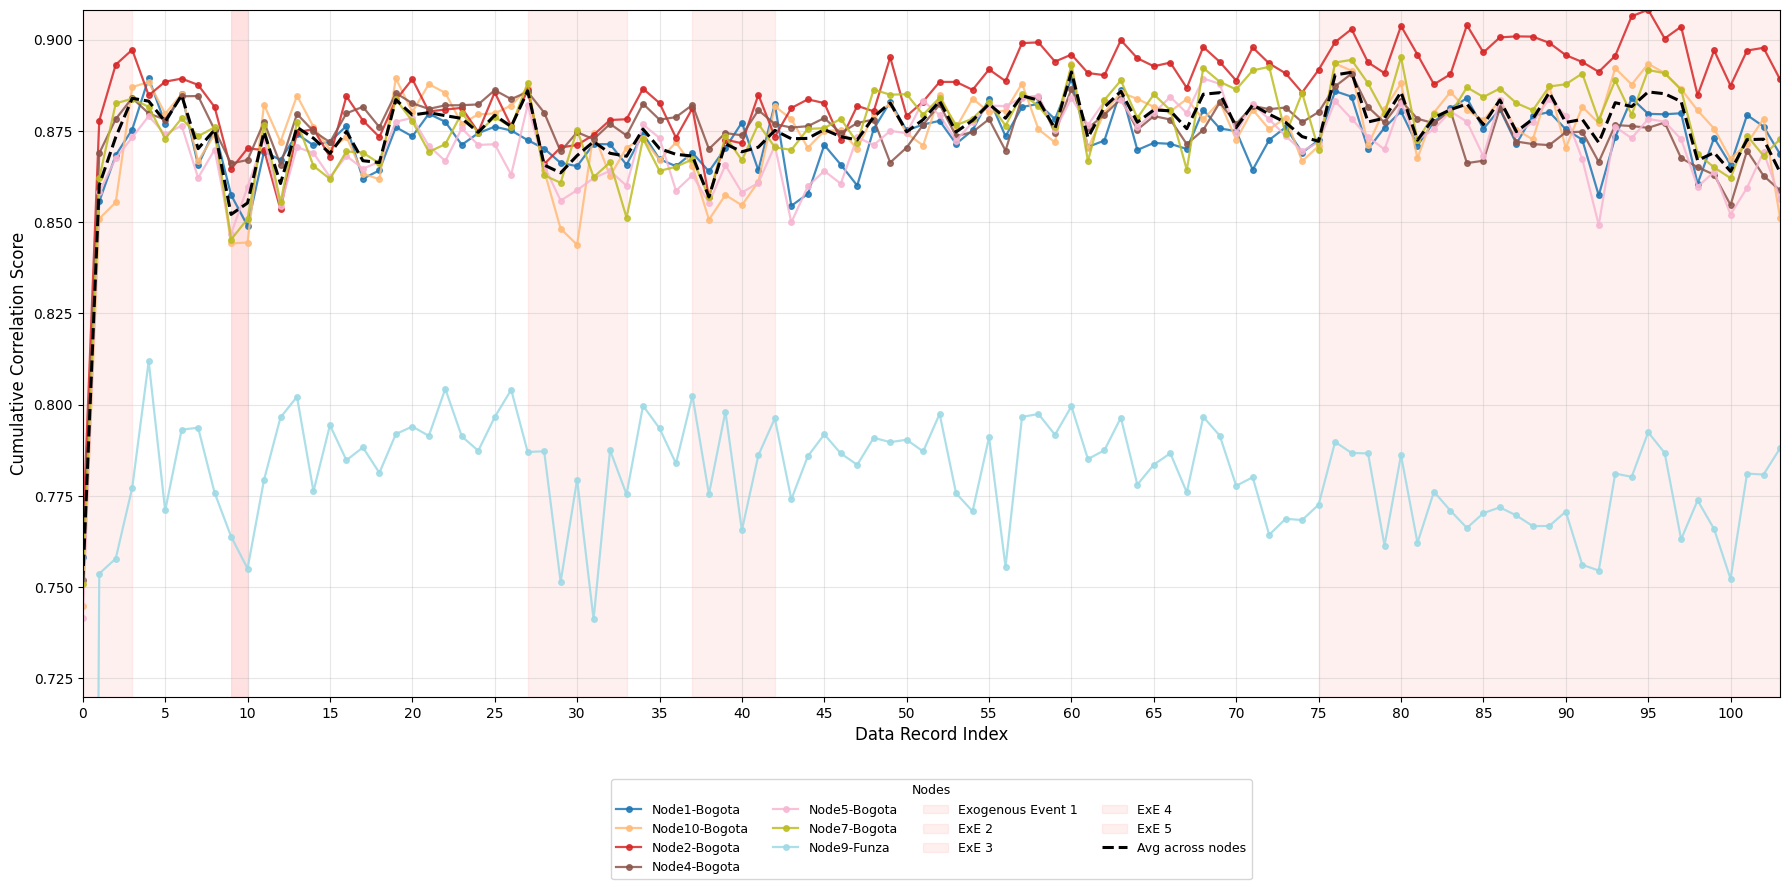

In [8]:
# =============================================================================
# PLOT: Cumulative correlation scores per node across all data_records
# =============================================================================

cmap = plt.colormaps['tab20'].resampled(n_nodes)

fig, ax = plt.subplots(figsize=(18, 9))

# Create normalized dictionary: all_ranked_scores[node] 
all_ranked_scores_ = {
    node: np.array(scores) / (n_nodes - 1) 
    for node, scores in all_ranked_scores.items()
}

global_max = max(max(scores) for scores in all_ranked_scores_.values())

for idx, node in enumerate(sorted(datos_nodos.keys())):
    scores_over_time = all_ranked_scores_[node]
    ax.plot(records, scores_over_time,
            label=short_name(node),
            color=cmap(idx),
            linewidth=1.6,
            marker='o', markersize=4,
            alpha=0.85)


# Overlay average as dashed horizontal lines
for idx, (node, avg) in enumerate(avg_sorted.items()):
    ax.axhline(y=avg, color=cmap(list(avg_sorted.keys()).index(node)),
               linestyle='--', linewidth=0.75, alpha=0.42)

ax.set_xlabel("Data Record Index", fontsize=12)
ax.set_ylabel("Cumulative Correlation Score", fontsize=12)
ax.set_xticks(records)
ax.set_xlim(0,103)
ax.set_ylim(.72,global_max)

# 🔹 Multiple zones (e.g., training vs. testing split)
ax.axvspan(9, 10, color='red', alpha=0.06, linewidth=0)
ax.axvspan(0, 3, color='red', alpha=0.06, label='Exogenous Event 1')
ax.axvspan(9, 10, color='red', alpha=0.06, label='ExE 2')
ax.axvspan(27, 33, color='red', alpha=0.06, label='ExE 3')
ax.axvspan(37, 42, color='red', alpha=0.06, label='ExE 4')
ax.axvspan(75, 103, color='red', alpha=0.06, label='ExE 5')
ax.plot(records, avg_score_per_record,
        color='black', linewidth=2.2, linestyle='--',
        zorder=10, label='Avg across nodes')
max_record = safe_max+1  # or: max_record = len(records) - 1
ax.set_xticks(range(0, max_record + 1, 5))
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    fontsize=9,
    title="Nodes",
    title_fontsize=9,
    borderaxespad=0,
    ncol=4
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


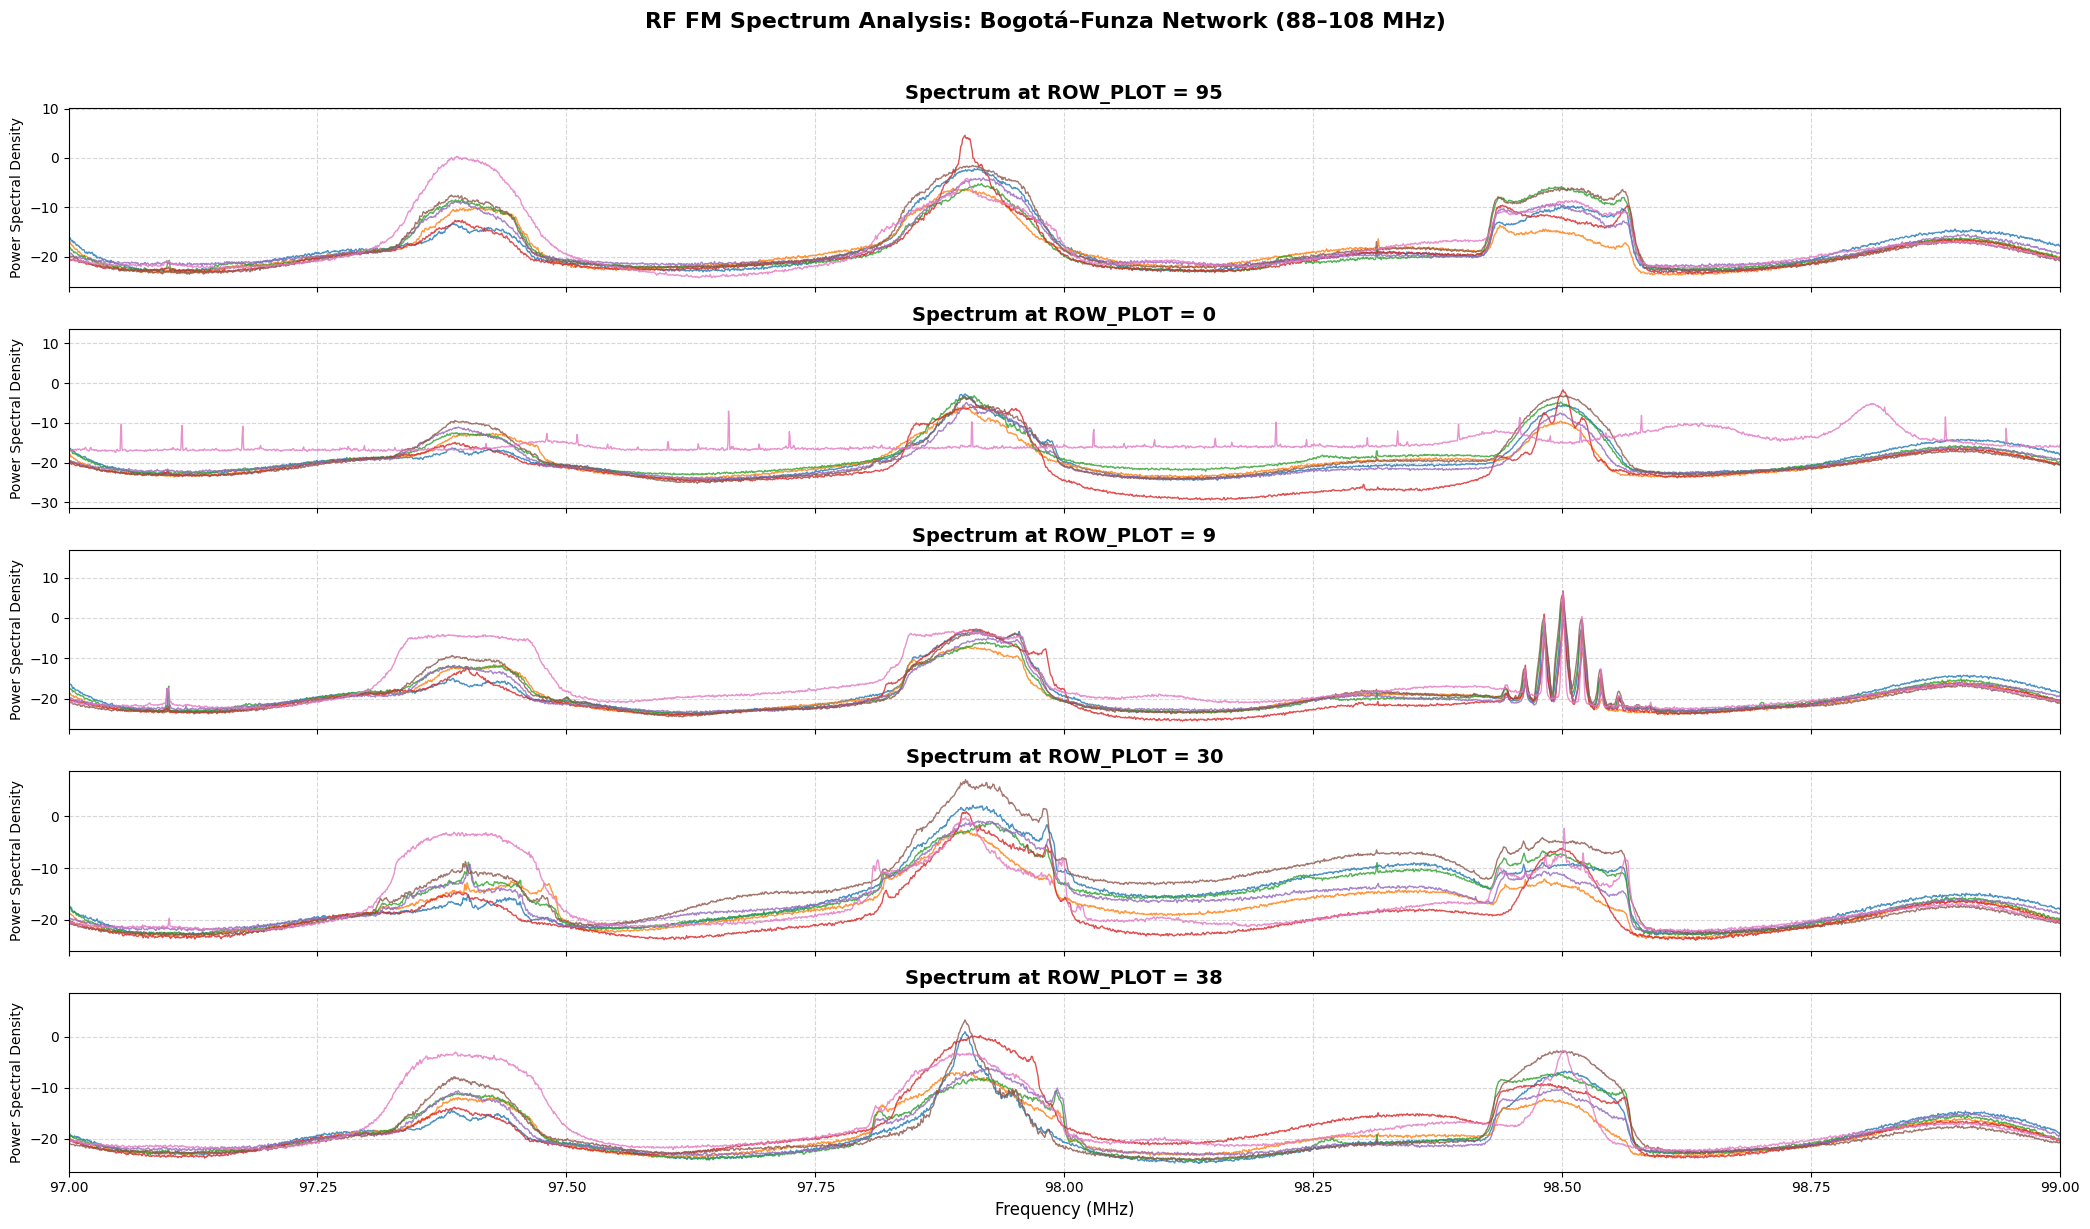

In [9]:
# Row indices to plot
row_indices = [95, 0, 9,30,38]

# Create figure with  subplots (one per ROW_PLOT value)
fig, axes = plt.subplots(nrows=len(row_indices), ncols=1, figsize=(21, 12), sharex=True)

# Ensure axes is iterable even if only one row
if len(row_indices) == 1:
    axes = [axes]

for ax, row_idx in zip(axes, row_indices):
    
    for nombre_nodo, df in datos_nodos.items():
        # ⚠️ Safety check: ensure row_idx exists in this node's DataFrame
        if row_idx >= len(df):
            continue
            
        # Extract and parse the pxx spectrum list from the specified row
        pxx = ast.literal_eval(df['pxx'].iloc[row_idx])
        frecuencias = np.linspace(88, 108, len(pxx))  # FM band: 88–108 MHz
        
        # Plot spectrum for this node
        ax.plot(frecuencias, pxx, label=nombre_nodo, linewidth=1, alpha=0.8)
    
    # Configure subplot appearance
    ax.set_title(f'Spectrum at ROW_PLOT = {row_idx}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Power Spectral Density', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(97,99)

# Common x-axis label and title for the entire figure
axes[-1].set_xlabel('Frequency (MHz)', fontsize=12)
fig.suptitle('RF FM Spectrum Analysis: Bogotá–Funza Network (88–108 MHz)', 
             fontsize=16, fontweight='bold', y=1.02)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

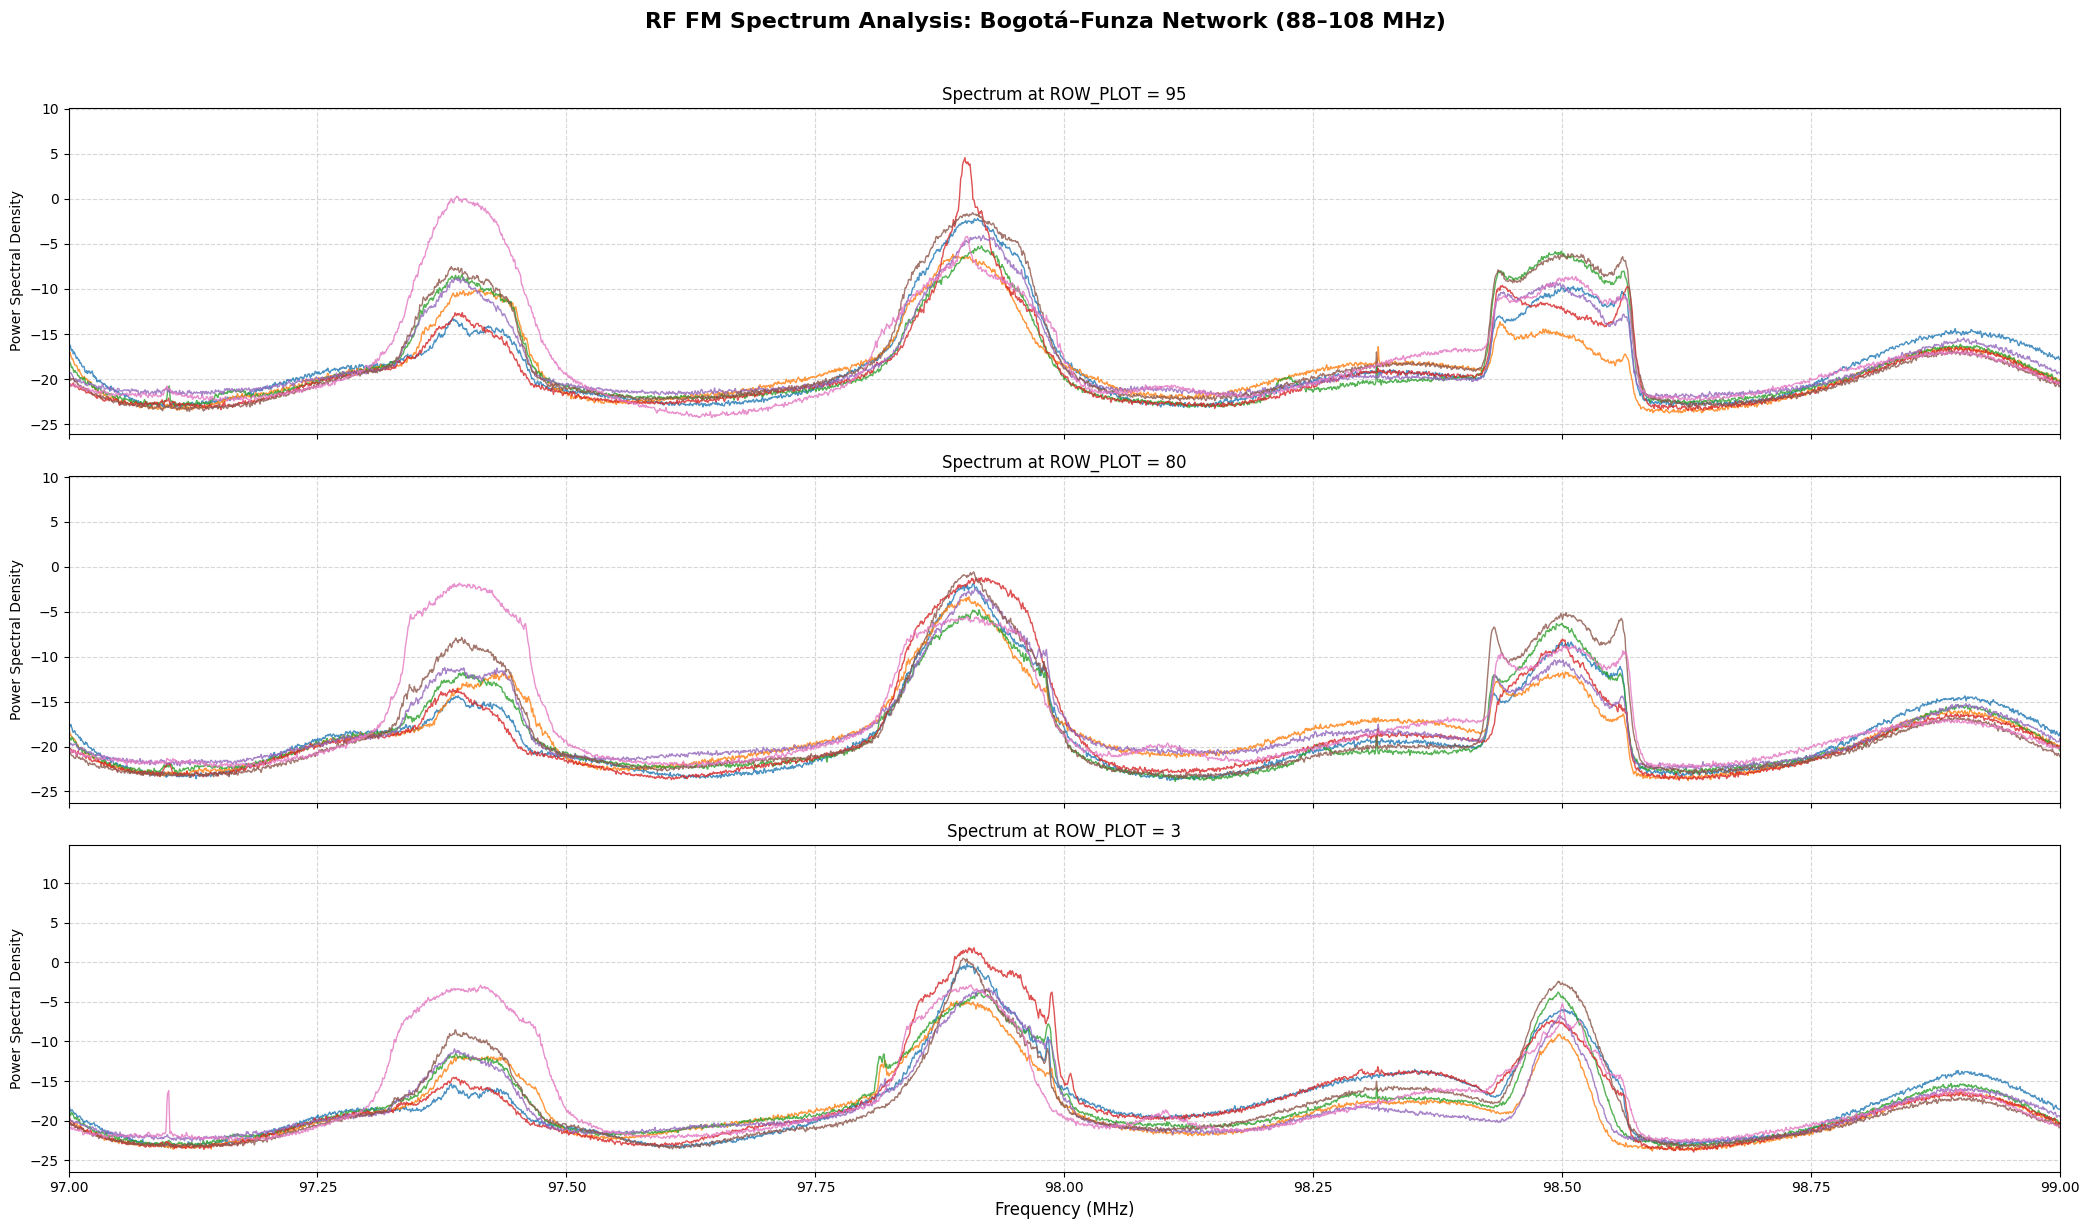

In [10]:
row_indices = [95,80, 3]

# Create figure with  subplots (one per ROW_PLOT value)
fig, axes = plt.subplots(nrows=len(row_indices), ncols=1, figsize=(21, 12), sharex=True)

# Ensure axes is iterable even if only one row
if len(row_indices) == 1:
    axes = [axes]

for ax, row_idx in zip(axes, row_indices):
    
    for nombre_nodo, df in datos_nodos.items():
        # ⚠️ Safety check: ensure row_idx exists in this node's DataFrame
        if row_idx >= len(df):
            continue
            
        # Extract and parse the pxx spectrum list from the specified row
        pxx = ast.literal_eval(df['pxx'].iloc[row_idx])
        frecuencias = np.linspace(88, 108, len(pxx))  # FM band: 88–108 MHz
        
        # Plot spectrum for this node
        ax.plot(frecuencias, pxx, label=nombre_nodo, linewidth=1, alpha=0.8)
    
    # Configure subplot appearance
    ax.set_title(f'Spectrum at ROW_PLOT = {row_idx}', fontsize=12)
    ax.set_ylabel('Power Spectral Density', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(97,99)

# Common x-axis label and title for the entire figure
axes[-1].set_xlabel('Frequency (MHz)', fontsize=12)
fig.suptitle('RF FM Spectrum Analysis: Bogotá–Funza Network (88–108 MHz)', 
             fontsize=16, fontweight='bold', y=1.02)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()